# LIBS

In [135]:
import pandas as pd
import numpy as np

import json

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# DATA 1

## EDA

### DATA LOADING

In [126]:
df1 = pd.read_csv('../datasets/fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv')

### DATA INSPECTION

In [128]:
print(df1.shape)
print(df1.info())
print(df1.dtypes)

print(df1.isnull().sum())

print("Duplikat exact row:", df1.duplicated().sum())
print("Duplikat berdasarkan lokasi+waktu (lat/long/acq_date/acq_time):",
      df1.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time']).sum())

print(df1['satellite'].value_counts())
print(df1['instrument'].value_counts())
print(df1['confidence'].value_counts())
print(df1['daynight'].value_counts())
print(df1['type'].value_counts())
print(df1['version'].value_counts())

(61583, 15)
<class 'pandas.DataFrame'>
RangeIndex: 61583 entries, 0 to 61582
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    61583 non-null  float64
 1   longitude   61583 non-null  float64
 2   brightness  61583 non-null  float64
 3   scan        61583 non-null  float64
 4   track       61583 non-null  float64
 5   acq_date    61583 non-null  str    
 6   acq_time    61583 non-null  int64  
 7   satellite   61583 non-null  str    
 8   instrument  61583 non-null  str    
 9   confidence  61583 non-null  str    
 10  version     61583 non-null  int64  
 11  bright_t31  61583 non-null  float64
 12  frp         61583 non-null  float64
 13  daynight    61583 non-null  str    
 14  type        61583 non-null  int64  
dtypes: float64(7), int64(3), str(5)
memory usage: 7.0 MB
None
latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date          st

> satellite, instrument, version, dan type semuanya bernilai konstan (N20, VIIRS, versi 2, tipe 0/presumed vegetation fire). Artinya dataset ini adalah *feed* satu sumber (satelit NOAA-20, sensor VIIRS) yang sudah terfilter khusus kebakaran vegetasi. Ksolom-kolom ini bisa disimpan sebagai metadata/dokumentasi *provenance*, tapi tidak akan memberi variasi apa pun untuk analisis lebih lanjut (tidak perlu jadi fitur pembeda).

In [130]:
# Statistik deskriptif FRP & brightness
print(df1[['frp', 'brightness', 'bright_t31']].describe())

# Proporsi confidence
print(df1['confidence'].value_counts(normalize=True).mul(100).round(2))

# Proporsi day/night
print(df1['daynight'].value_counts(normalize=True).mul(100).round(2))

# Parsing acq_date
acq_date_parsed = pd.to_datetime(df1['acq_date'])
print("\nRentang tanggal:", acq_date_parsed.min(), "-", acq_date_parsed.max())
print("Jumlah hari unik terekam:", acq_date_parsed.dt.date.nunique())

# Tren jumlah titik api per tanggal
daily_counts = acq_date_parsed.dt.date.value_counts().sort_index()
print(daily_counts.describe())

                frp    brightness    bright_t31
count  61583.000000  61583.000000  61583.000000
mean      10.569943    335.869756    292.131284
std       17.423736     13.676556      6.516525
min        0.090000    207.930000    241.480000
25%        3.580000    331.290000    289.390000
50%        6.140000    335.860000    292.990000
75%       11.430000    342.220000    296.270000
max      954.790000    367.000000    361.810000
confidence
n    93.07
h     3.77
l     3.16
Name: proportion, dtype: float64
daynight
D    89.29
N    10.71
Name: proportion, dtype: float64

Rentang tanggal: 2024-08-01 00:00:00 - 2026-05-31 00:00:00
Jumlah hari unik terekam: 629
count     629.000000
mean       97.906200
std       242.703895
min         1.000000
25%         7.000000
50%        20.000000
75%        69.000000
max      2400.000000
Name: count, dtype: float64


> ada 2 poin yang perlu diperhatikan:
> - FRP terkonfirmasi skew karena nilai mean (10,57) yang jauh di atas median (6,14), dengan std (17,42) bahkan lebih besar dari mean. Ini bukan anomali.
> - brightness & bright_t31 punya batas yang perlu dilakukan *cross-check* pada nilai min brightness = 207,93 (dibulatkan ~208) dan max = 367,00 (angka bulat persis). Ini merupakan batas fisik dari rentang deteksi sensor VIIRS (nilai dipotong/clip di titik tertentu, bukan representasi suhu sebenarnya di ekstrem). Perlu dicek berapa banyak baris yang persis menyentuh batas ini, karena itu artinya intensitas api sebenarnya di titik-titik itu bisa jadi *underestimated*.

> **PENTING!**
> Rentang 2024-08-01 s/d 2026-05-31 mencakup ~22 bulan. Ini lebih dari satu musim kering, kemungkinan mencakup 2 siklus musim kering (2024 dan 2025) ditambah data awal 2026. Perlu dicek distribusi bulanannya untuk konfirmasi pola musiman sebelum klaim "musim kering" di laporan.

In [132]:
# Saturasi sensor pada brightness & bright_t31
print("Baris brightness == min:", (df1['brightness'] == df1['brightness'].min()).sum())
print("Baris brightness == max:", (df1['brightness'] == df1['brightness'].max()).sum())
print("Baris bright_t31 == max:", (df1['bright_t31'] == df1['bright_t31'].max()).sum())

# Distribusi bulanan (untuk validasi pola musim kering)
acq_date_parsed = pd.to_datetime(df1['acq_date'])
month_counts = acq_date_parsed.dt.to_period('M').value_counts().sort_index()
print("\nJumlah titik api per bulan:")
print(month_counts)

# Identifikasi hari dengan titik api terbanyak
daily_counts = acq_date_parsed.dt.date.value_counts().sort_index()
peak_date = daily_counts.idxmax()
print(f"\nTanggal terbanyak: {peak_date}, jumlah titik api: {daily_counts.max()}")

Baris brightness == min: 57
Baris brightness == max: 2328
Baris bright_t31 == max: 1

Jumlah titik api per bulan:
acq_date
2024-08     3539
2024-09    16911
2024-10     3744
2024-11      534
2024-12      156
2025-01      124
2025-02      308
2025-03      252
2025-04      222
2025-05      710
2025-06      682
2025-07     7508
2025-08     7269
2025-09     9076
2025-10     2646
2025-11      755
2025-12      183
2026-01     2027
2026-02      640
2026-03     2577
2026-04     1034
2026-05      686
Freq: M, Name: count, dtype: int64

Tanggal terbanyak: 2024-09-03, jumlah titik api: 2400


> Poin-poin penting:
> - Saturasi sensor cukup signifikan: 2.328 baris (~3,8% dari total data) menyentuh persis nilai maksimum brightness (367,00). Artinya untuk ~3,8% titik api "terpanas", suhu sebenarnya kemungkinan di atas yang tercatat (sensor mentok, bukan representasi akurat). Ini layak dicatat sebagai keterbatasan data, terutama karena titik-titik inilah yang justru paling relevan untuk prioritas *dispatch*.
> - Pola musiman terkonfirmasi, tapi dengan catatan: puncak jelas terjadi di Agustus-Oktober pada kedua tahun (2024: 3.539 -> 16.911 -> 3.744; 2025: 7.508 -> 7.269 -> 9.076), konsisten dengan narasi musim kering di *problem description*. Namun September 2024 (16.911) jauh lebih ekstrem dibanding puncak 2025 manapun (maks 9.076). Ini indikasi 2024 kemungkinan tahun krisis yang jauh lebih parah (bisa jadi terkait fenomena iklim seperti El Nino, tapi ini perlu verifikasi eksternal, tidak bisa disimpulkan dari dataset ini sendiri).
> - Ada juga lonjakan kecil di luar musim kering (Jan & Mar 2026: 2.027 & 2.577), di luar pola "normal" Nov-Jun yang biasanya rendah. Ini bisa jadi anomali lokal atau memang layak dicek lebih lanjut di tahap sebaran spasial selanjutnya.

### DATA VISUALIZATION

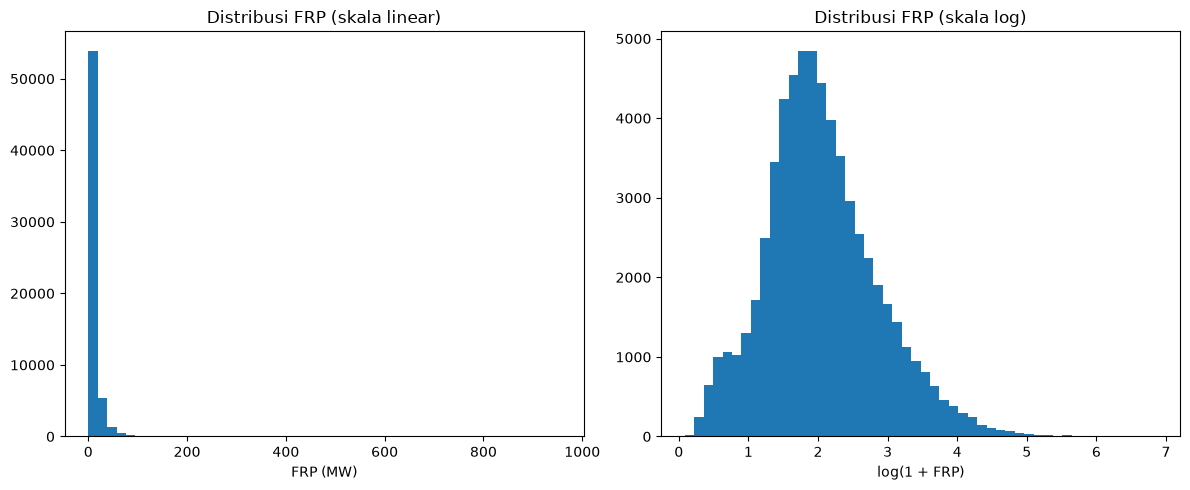

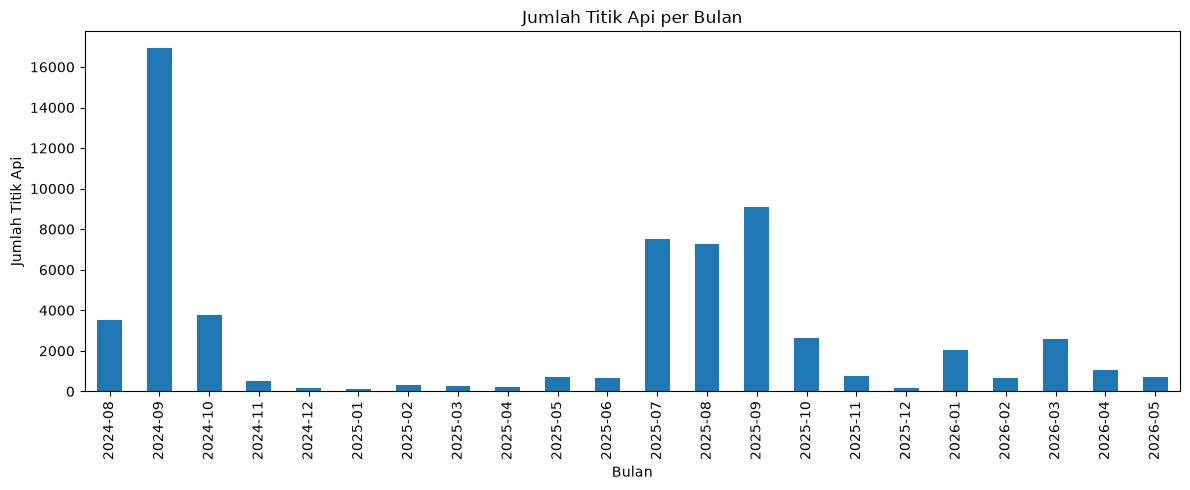

In [138]:
# Histogram FRP (linear vs log scale)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(df1['frp'], bins=50)
axes[0].set_title('Distribusi FRP (skala linear)')
axes[0].set_xlabel('FRP (MW)')

axes[1].hist(np.log1p(df1['frp']), bins=50)
axes[1].set_title('Distribusi FRP (skala log)')
axes[1].set_xlabel('log(1 + FRP)')
plt.tight_layout()
plt.show()

# Tren jumlah titik api per bulan
month_counts = pd.to_datetime(df1['acq_date']).dt.to_period('M').value_counts().sort_index()
month_counts.plot(kind='bar', figsize=(12,5))
plt.title('Jumlah Titik Api per Bulan')
plt.ylabel('Jumlah Titik Api')
plt.xlabel('Bulan')
plt.tight_layout()
plt.show()

Rentang latitude : -4.17349 - 4.35095
Rentang longitude: 108.6836 - 119.49944

Jumlah titik dengan longitude > 118: 1250
          latitude    longitude
count  1250.000000  1250.000000
mean     -0.978339   118.872581
std       2.011052     0.528006
min      -3.696920   118.000020
25%      -2.672168   118.244045
50%      -2.009060   119.083160
75%       1.377200   119.347095
max       2.353760   119.499440


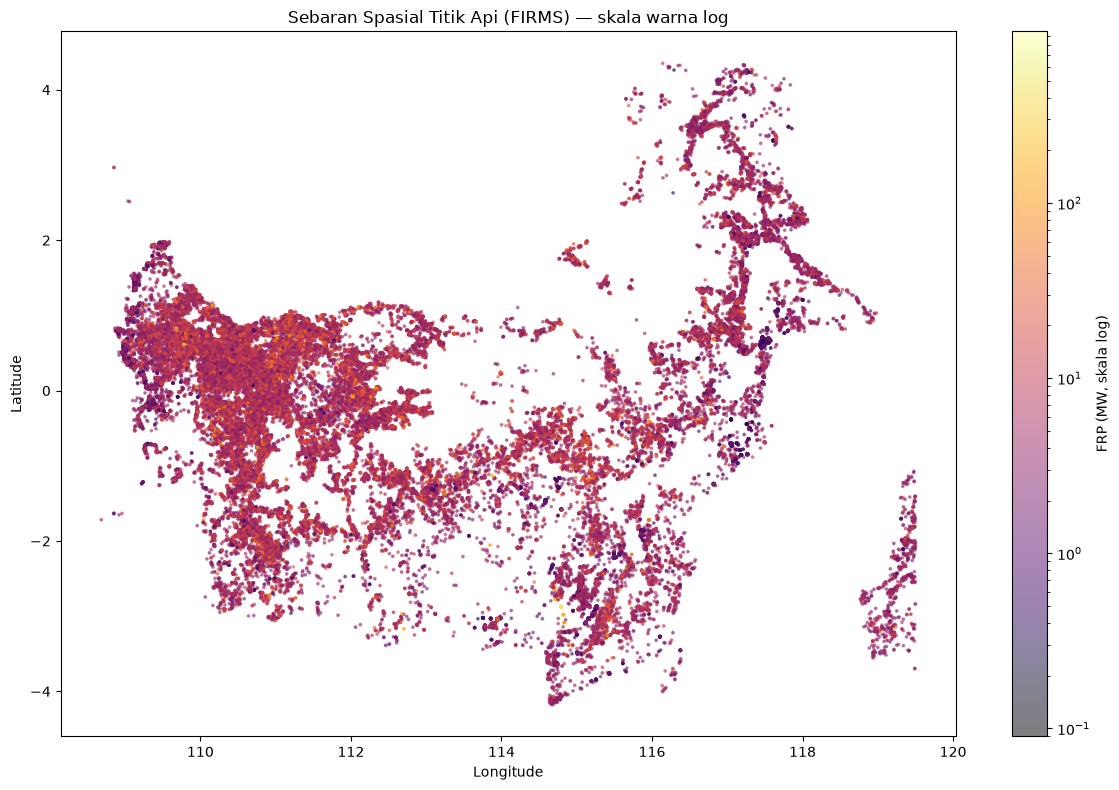

In [137]:
# Cek bounding box aktual data
print("Rentang latitude :", df1['latitude'].min(), "-", df1['latitude'].max())
print("Rentang longitude:", df1['longitude'].min(), "-", df1['longitude'].max())

# Isolasi klaster yang tampak terpisah di sisi timur
detached = df1[df1['longitude'] > 118]
print("\nJumlah titik dengan longitude > 118:", len(detached))
print(detached[['latitude', 'longitude']].describe())

# Scatter ulang dengan skala warna LOG
plt.figure(figsize=(12,8))
sc = plt.scatter(
    df1['longitude'], df1['latitude'], c=df1['frp'],
    cmap='inferno',
    norm=mcolors.LogNorm(vmin=df1['frp'].min(), vmax=df1['frp'].max()),
    s=3, alpha=0.5
)
plt.colorbar(sc, label='FRP (MW, skala log)')
plt.title('Sebaran Spasial Titik Api (FIRMS) — skala warna log')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

> Ada klaster area yang terlihat terpisah di pojok kanan bawah grafik. Ada 2 kemungkinan: (a) ujung timur laut Kalimantan Timur yang memang menyambung ke badan utama (lat 0 sampai 4, masih bagian pulau), dan (b) klaster yang benar-benar terpisah secara visual di kuadran kanan-bawah (lat negatif, long 118-119,5), pola diagonal yang terlihat di gambar itu justru cocok secara geografis dengan pesisir barat Sulawesi (Sulawesi Barat/Selatan), di seberang Selat Makassar dari Kalimantan Timur.

### PREPROCESSING

In [141]:
# Isolasi khusus klaster yang terlihat terpisah secara visual (long>118 DAN lat<0)
detached_south = df1[(df1['longitude'] > 118) & (df1['latitude'] < 0)]
print("Jumlah titik pada klaster terpisah (dugaan luar Kalimantan):", len(detached_south))
print(detached_south[['latitude', 'longitude']].describe())
print(f"\nPersentase dari total data: {len(detached_south)/len(df1)*100:.2f}%")

# Bandingkan dengan titik long>118 TAPI lat>=0
still_kalimantan_east = df1[(df1['longitude'] > 118) & (df1['latitude'] >= 0)]
print("\nJumlah titik long>118 & lat>=0 (dugaan masih Kalimantan):", len(still_kalimantan_east))

Jumlah titik pada klaster terpisah (dugaan luar Kalimantan): 771
         latitude   longitude
count  771.000000  771.000000
mean    -2.509611  119.250627
std      0.578261    0.190641
min     -3.696920  118.766750
25%     -3.031970  119.139510
50%     -2.510650  119.287490
75%     -2.032190  119.401620
max     -1.074100  119.499440

Persentase dari total data: 1.25%

Jumlah titik long>118 & lat>=0 (dugaan masih Kalimantan): 479


> klaster ini rapat dan konsisten (std kecil, rentang latitude -3,7 sampai -1,07, longitude 118,77-119,5), bukan noise acak, tapi memang klaster geografis nyata yang terpisah dari badan utama Kalimantan, kemungkinan bagian Sulawesi Barat. Sekitar 771 baris (1,25%) dari total data.

Baris df1 asli          : 61583
Baris df1_kalimantan    : 60812
Baris dikecualikan      : 771

dtype acq_date setelah parsing: datetime64[us]


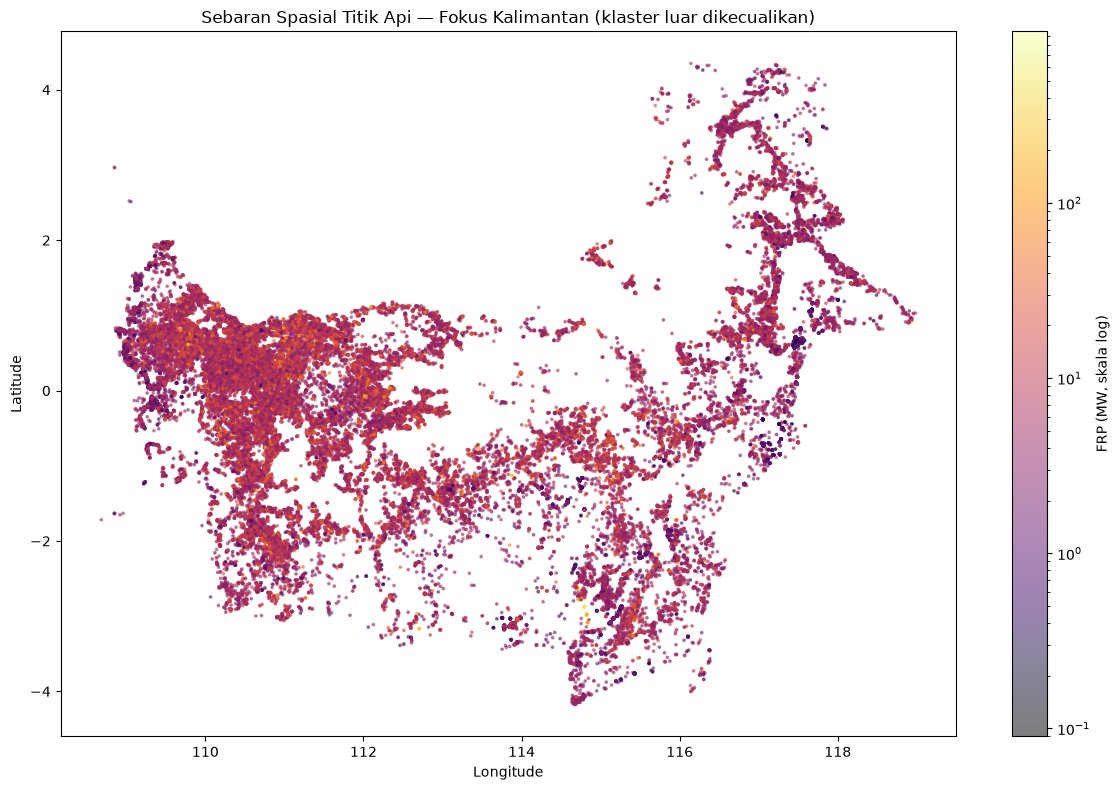

In [143]:
# Subset khusus Kalimantan
df1_kalimantan = df1[~((df1['longitude'] > 118) & (df1['latitude'] < 0))].reset_index(drop=True)

print(f"Baris df1 asli          : {len(df1)}")
print(f"Baris df1_kalimantan    : {len(df1_kalimantan)}")
print(f"Baris dikecualikan      : {len(df1) - len(df1_kalimantan)}")

# Finalisasi parsing acq_date jadi permanent
df1['acq_date'] = pd.to_datetime(df1['acq_date'])
df1_kalimantan['acq_date'] = pd.to_datetime(df1_kalimantan['acq_date'])
print("\ndtype acq_date setelah parsing:", df1['acq_date'].dtype)

# Scatter subset Kalimantan
plt.figure(figsize=(12,8))
sc = plt.scatter(
    df1_kalimantan['longitude'], df1_kalimantan['latitude'], c=df1_kalimantan['frp'],
    cmap='inferno', norm=mcolors.LogNorm(vmin=df1_kalimantan['frp'].min(), vmax=df1_kalimantan['frp'].max()),
    s=3, alpha=0.5
)
plt.colorbar(sc, label='FRP (MW, skala log)')
plt.title('Sebaran Spasial Titik Api — Fokus Kalimantan (klaster luar dikecualikan)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

> Scatter plot sudah fokus menampilkan titik data hanya pada Pulau Kalimantan.

# DATA 3

## EDA

### DATA LOADING

In [54]:
with open('../datasets/indonesia-province-jml-penduduk.json', 'r') as f:
    data = json.load(f)

print(data.keys())

dict_keys(['type', 'features'])


In [55]:
print(len(data['features']))
print(data['features'][0])

32
{'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[137.916656, -1.49852], [137.8926, -1.46795], [137.8975, -1.47042], [137.8988, -1.46935], [137.9026, -1.46724], [137.9057, -1.46616], [137.911, -1.46451], [137.9133, -1.46337], [137.9152, -1.46212], [137.9165, -1.46172], [137.9182, -1.46309], [137.9196, -1.4643], [137.9215, -1.46762], [137.9232, -1.47415], [137.9236, -1.47684], [137.9247, -1.4801], [137.9264, -1.48416], [137.9285, -1.48817], [137.9307, -1.49252], [137.9328, -1.49578], [137.9338, -1.49744], [137.9339, -1.49945], [137.9333, -1.50162], [137.9327, -1.50317], [137.9327, -1.50368], [137.9337, -1.50368], [137.9357, -1.50259], [137.9376, -1.50191], [137.9394, -1.50209], [137.9433, -1.50479], [137.9478, -1.50783], [137.9504, -1.5096], [137.957, -1.51504], [137.9605, -1.51734], [137.9624, -1.51883], [137.9638, -1.52107], [137.9644, -1.52392], [137.9646, -1.52576], [137.9648, -1.52782], [137.9638, -1.53056], [137.9629, -1.53159], [137.9614, -1.5325], [1

In [56]:
print(data['features'][0]['properties'])

{'ID': 1, 'kode': 85, 'Propinsi': 'IRIAN JAYA TIMUR', 'SUMBER': 'Peta Dasar BAKOSURTANAL Skala 1 : 250.000', 'Jumlah Penduduk': 1416690}


In [57]:
df3 = pd.DataFrame([
    feature['properties']
    for feature in data['features']
])

In [58]:
df3.head()

,ID,kode,Propinsi,SUMBER,Jumlah Penduduk
0,1,85,IRIAN JAYA TIMUR,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,1416690
1,2,52,NUSATENGGARA BARAT,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,4500212
2,3,75,GORONTALO,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,1040164
3,4,74,SULAWESI TENGGARA,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,2232586
4,5,34,DAERAH ISTIMEWA YOGYAKARTA,Peta Dasar BAKOSURTANAL Skala 1 : 250.000,3457491


In [59]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               32 non-null     int64
 1   kode             32 non-null     int64
 2   Propinsi         32 non-null     str  
 3   SUMBER           32 non-null     str  
 4   Jumlah Penduduk  32 non-null     int64
dtypes: int64(3), str(2)
memory usage: 1.4 KB


In [60]:
df3.describe()

,ID,kode,Jumlah Penduduk
count,32.000000,32.000000,3.200000e+01
mean,16.500000,146.718750,7.337610e+06
std,9.380832,581.389672,1.042569e+07
min,1.000000,0.000000,7.604220e+05
25%,8.750000,16.750000,2.087946e+06
50%,16.500000,43.500000,3.758686e+06
75%,24.250000,73.250000,7.489897e+06
max,32.000000,3329.000000,4.305373e+07


In [62]:
df3.shape

(32, 5)

### STRUCTURE & QUALITY

In [64]:
# Missing values
print(df3.isnull().sum())

# Duplikasi
print("\nDuplikat exact row     :", df3.duplicated().sum())
print("Duplikat nama provinsi :", df3['Propinsi'].duplicated().sum())

# Kardinalitas & sanity check nama provinsi
print("\nJumlah provinsi unik   :", df3['Propinsi'].nunique())
print(sorted(df3['Propinsi'].unique()))
print(df3['SUMBER'].value_counts())

ID                 0
kode               0
Propinsi           0
SUMBER             0
Jumlah Penduduk    0
dtype: int64

Duplikat exact row     : 0
Duplikat nama provinsi : 0

Jumlah provinsi unik   : 32
['BALI', 'BANGKA BELITUNG', 'BENGKULU', 'DAERAH ISTIMEWA YOGYAKARTA', 'DI. ACEH', 'DKI JAKARTA', 'GORONTALO', 'IRIAN JAYA BARAT', 'IRIAN JAYA TENGAH', 'IRIAN JAYA TIMUR', 'JAMBI', 'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALIMANTAN TIMUR', 'LAMPUNG', 'MALUKU', 'MALUKU UTARA', 'NUSA TENGGARA TIMUR', 'NUSATENGGARA BARAT', 'PROBANTEN', 'RIAU', 'SULAWESI SELATAN', 'SULAWESI TENGAH', 'SULAWESI TENGGARA', 'SULAWESI UTARA', 'SUMATERA BARAT', 'SUMATERA SELATAN', 'SUMATERA UTARA']
SUMBER
Peta Dasar BAKOSURTANAL Skala 1 : 250.000    32
Name: count, dtype: int64


> Ada typo pada provinsi 'PROBANTEN' yang seharusnya 'BANTEN'.

In [65]:
# Perbaikan typo nama provinsi
df3['Propinsi'] = df3['Propinsi'].replace({'PROBANTEN': 'BANTEN'})

### DATA INSPECTION

In [68]:
print(df3['Jumlah Penduduk'].describe())

# Top 5 & bottom 5 provinsi berdasarkan populasi
df3_sorted = df3.sort_values('Jumlah Penduduk', ascending=False)
print("\nTop 5 provinsi terpadat:")
print(df3_sorted[['Propinsi', 'Jumlah Penduduk']].head(5))
print("\nBottom 5 provinsi:")
print(df3_sorted[['Propinsi', 'Jumlah Penduduk']].tail(5))

# Total agregat
print("\nTotal agregat penduduk (32 provinsi):", df3['Jumlah Penduduk'].sum())

count    3.200000e+01
mean     7.337610e+06
std      1.042569e+07
min      7.604220e+05
25%      2.087946e+06
50%      3.758686e+06
75%      7.489897e+06
max      4.305373e+07
Name: Jumlah Penduduk, dtype: float64

Top 5 provinsi terpadat:
          Propinsi  Jumlah Penduduk
14      JAWA BARAT         43053732
7       JAWA TIMUR         37476757
5      JAWA TENGAH         32382657
23  SUMATERA UTARA         12982204
6           BANTEN         10632166

Bottom 5 provinsi:
             Propinsi  Jumlah Penduduk
15  IRIAN JAYA TENGAH          1416690
24    BANGKA BELITUNG          1223296
2           GORONTALO          1040164
8        MALUKU UTARA          1038087
22   IRIAN JAYA BARAT           760422

Total agregat penduduk (32 provinsi): 234803511


In [70]:
# Khusus Provinsi di Kalimantan
provinsi_kalimantan = [
    'KALIMANTAN BARAT',
    'KALIMANTAN TENGAH',
    'KALIMANTAN SELATAN',
    'KALIMANTAN TIMUR',
    'KALIMANTAN UTARA'
]

df_kalimantan = df3[
    df3['Propinsi'].isin(provinsi_kalimantan)
].copy()

df_kalimantan_sorted = df_kalimantan.sort_values(
    'Jumlah Penduduk',
    ascending=False
)

print("Penduduk provinsi di Kalimantan:")
print(
    df_kalimantan_sorted[
        ['Propinsi', 'Jumlah Penduduk']
    ].to_string(index=False)
)

print(
    "\nTotal penduduk Kalimantan:",
    df_kalimantan['Jumlah Penduduk'].sum()
)

Penduduk provinsi di Kalimantan:
          Propinsi  Jumlah Penduduk
  KALIMANTAN BARAT          4395983
KALIMANTAN SELATAN          3626616
  KALIMANTAN TIMUR          3553143
 KALIMANTAN TENGAH          2212089

Total penduduk Kalimantan: 13787831


> Setelah dilakukan *cross-check* dan mencocokkan angka penduduk pada beberapa sumber, ternyata dataset ini merupakan *snapshot* dari sekitar tahun 2010.
> Pertimbangannya untuk dataset ini adalah:
> - **Tidak relevan digunakan** jika membutuhkan data angka absolut presisi terbaru (misalnya estimasi jumlah korban terpapar asap per provinsi)

# DATA 4

## EDA

### DATA LOADING

In [71]:
df4 = pd.read_csv('../datasets/complete_data.csv')
df4.head()

,province_name,city_name,district_name,school_name,stage,status,lat,long,province_area,total_population,total_education_age_population
0,PAPUA,Kab. Tolikara,Kec. Gilungbandu,SMP SATAP KAGI,SMP,N,-3.415995,138.339704,319036,4418581.0,1517814
1,PAPUA,Kab. Tolikara,Kec. Wunin,SD YPPGI WURINERI,SD,S,-3.479000,138.680000,319036,4418581.0,1517814
2,PAPUA,Kab. Tolikara,Kec. Bokondini,SMAN BOKONDINI,SMA,N,-3.531731,138.658234,319036,4418581.0,1517814
3,PAPUA,Kab. Tolikara,Kec. Kuari,SD INPRES KUARI,SD,N,-3.518100,138.529500,319036,4418581.0,1517814
4,PAPUA,Kab. Tolikara,Kec. Karubaga,SMAS YPPGI KARUBAGA,SMA,S,-3.449100,138.598800,319036,4418581.0,1517814


In [72]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 215371 entries, 0 to 215370
Data columns (total 11 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   province_name                   215371 non-null  str    
 1   city_name                       215371 non-null  str    
 2   district_name                   215371 non-null  str    
 3   school_name                     215371 non-null  str    
 4   stage                           215371 non-null  str    
 5   status                          215371 non-null  str    
 6   lat                             214221 non-null  float64
 7   long                            214221 non-null  float64
 8   province_area                   215371 non-null  int64  
 9   total_population                215371 non-null  float64
 10  total_education_age_population  215371 non-null  int64  
dtypes: float64(3), int64(2), str(6)
memory usage: 18.1 MB


In [73]:
df4.describe()

,lat,long,province_area,total_population,total_education_age_population
count,214221.000000,214221.000000,215371.000000,2.153710e+05,2.153710e+05
mean,-4.375879,110.698499,52654.765539,2.057260e+07,6.360771e+06
std,3.799361,32.465747,46684.233652,1.811042e+07,5.435455e+06
min,-10.930976,-333.000000,664.000000,7.277550e+05,2.456390e+05
25%,-7.317300,106.097067,32800.000000,5.407855e+06,1.880198e+06
50%,-6.188600,110.001900,42012.000000,1.067995e+07,3.235408e+06
75%,-1.496700,115.052000,57596.000000,4.114997e+07,1.158593e+07
max,108.210300,9720.000000,319036.000000,4.940581e+07,1.581126e+07


### STRUCTURE & QUALITY

In [74]:
# Missing values
print(df4.isnull().sum())

# Duplikasi
print("\nDuplikat exact row:", df4.duplicated().sum())
print("Duplikat nama sekolah + koordinat:",
      df4.duplicated(subset=['school_name', 'lat', 'long']).sum())

# Kardinalitas kolom kategorikal
print(df4['stage'].value_counts())
print(df4['status'].value_counts())
print("\nJumlah provinsi unik:", df4['province_name'].nunique())
print(sorted(df4['province_name'].unique()))

province_name                        0
city_name                            0
district_name                        0
school_name                          0
stage                                0
status                               0
lat                               1150
long                              1150
province_area                        0
total_population                     0
total_education_age_population       0
dtype: int64

Duplikat exact row: 1
Duplikat nama sekolah + koordinat: 87
stage
SD       148478
SMP       38045
SMK       13491
SMA       13181
SLB        1701
SDLB        242
SMPLB       124
SMLB        109
Name: count, dtype: int64
status
N    166417
S     48954
Name: count, dtype: int64

Jumlah provinsi unik: 34
['ACEH', 'BALI', 'BANTEN', 'BENGKULU', 'DI YOGYAKARTA', 'DKI JAKARTA', 'GORONTALO', 'JAMBI', 'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA', 'KEPULAUAN BANG

> Ada beberapa inkonsistensi penamaan provinsi antara data 3 dan 4. Tapi perlu diingat bahwa data 3 sudah turun statusnya menjadi referensi/dokumentasi karena sudah *outdated* dan sebaiknya tidak dipakai untuk perhitungan eksposur presisi. Juga tahap integrasi belum akan dilakukan sekarang (29/08/2026) karena fokus hari ini adalah melakukan analisis dan EDA sesuai hasil diskusi di grup DSA.

### DATA INSPECTION

In [75]:
# ringkasan total_population unik per provinsi
pop_check = df4.groupby('province_name')['total_population'].first().sort_values(ascending=False)
print(pop_check.head(10))

# Perbandingan dengan angka Jawa Barat
print("\nJawa Barat di Data 4:", pop_check.get('JAWA BARAT', 'nama provinsi tidak cocok, cek ejaan'))

province_name
JAWA BARAT          49405808.0
JAWA TIMUR          41149974.0
JAWA TENGAH         37032410.0
SUMATERA UTARA      15115206.0
BANTEN              12251985.0
DKI JAKARTA         10679951.0
SULAWESI SELATAN     9225747.0
LAMPUNG              9176546.0
SUMATERA SELATAN     8657008.0
RIAU                 6614384.0
Name: total_population, dtype: float64

Jawa Barat di Data 4: 49405808.00000001


> Untuk data 4 setelah dilakukan *cross-check* dan pencocokkan angka populasi ke banyak sumber salah satunya BPS, mengambil patokan angka pada Jawa Barat, dataset ini diperkirakan merupakan *snapshot* dari sekitar **tahun 2022**, dimana masih bisa dianggap relevan untuk digunakan.

In [83]:
# Statistik deskriptif
print(df4[['total_population', 'total_education_age_population', 'province_area']].describe())

# Rasio populasi usia sekolah terhadap total populasi
print('\n')
df4['pct_education_age'] = df4['total_education_age_population'] / df4['total_population']
print(df4['pct_education_age'].describe())

# Distribusi missing koordinat per provinsi
missing_coord = df4[df4['lat'].isnull()]
print("\nTotal baris missing koordinat:", len(missing_coord))
print(missing_coord['province_name'].value_counts())

       total_population  total_education_age_population  province_area
count      2.153710e+05                    2.153710e+05  215371.000000
mean       2.057260e+07                    6.360771e+06   52654.765539
std        1.811042e+07                    5.435455e+06   46684.233652
min        7.277550e+05                    2.456390e+05     664.000000
25%        5.407855e+06                    1.880198e+06   32800.000000
50%        1.067995e+07                    3.235408e+06   42012.000000
75%        4.114997e+07                    1.158593e+07   57596.000000
max        4.940581e+07                    1.581126e+07  319036.000000


count    215371.000000
mean          0.325153
std           0.028586
min           0.271886
25%           0.294746
50%           0.329098
75%           0.344246
max           0.381348
Name: pct_education_age, dtype: float64

Total baris missing koordinat: 1150
province_name
JAWA BARAT                   216
JAWA TIMUR                   193
ACEH              

> Rentang 27,2%–38,1% cukup masuk akal secara demografis untuk Indonesia (provinsi dengan struktur usia lebih muda seperti Papua/NTT wajar di angka lebih tinggi). Tidak ada anomali.

In [80]:
# Missing rate per provinsi
total_per_prov = df4['province_name'].value_counts()
missing_per_prov = df4[df4['lat'].isnull()]['province_name'].value_counts()

missing_rate = (missing_per_prov / total_per_prov * 100).round(2).sort_values(ascending=False)
print(missing_rate)

province_name
ACEH                         1.72
KALIMANTAN UTARA             1.68
KEPULAUAN RIAU               1.37
NUSA TENGGARA TIMUR          1.00
KALIMANTAN BARAT             0.98
SULAWESI TENGAH              0.95
JAWA BARAT                   0.73
JAWA TIMUR                   0.69
JAMBI                        0.69
PAPUA BARAT                  0.68
BANTEN                       0.61
PAPUA                        0.61
KEPULAUAN BANGKA BELITUNG    0.61
BENGKULU                     0.54
SULAWESI UTARA               0.51
GORONTALO                    0.51
NUSA TENGGARA BARAT          0.49
MALUKU                       0.47
RIAU                         0.42
SULAWESI SELATAN             0.40
BALI                         0.38
SULAWESI BARAT               0.37
SUMATERA SELATAN             0.34
MALUKU UTARA                 0.34
KALIMANTAN SELATAN           0.31
DKI JAKARTA                  0.31
SUMATERA UTARA               0.28
LAMPUNG                      0.27
KALIMANTAN TIMUR             0.24


> semua di bawah 2%, sebarannya relatif merata, tidak terkonsentrasi di satu wilayah tertentu.

### DATA DIAGNOSIS & VISUALIZATION

province_name
ACEH             1
BALI             1
BANTEN           1
BENGKULU         1
DI YOGYAKARTA    1
DKI JAKARTA      1
GORONTALO        1
JAMBI            1
JAWA BARAT       1
JAWA TENGAH      1
Name: total_education_age_population, dtype: int64


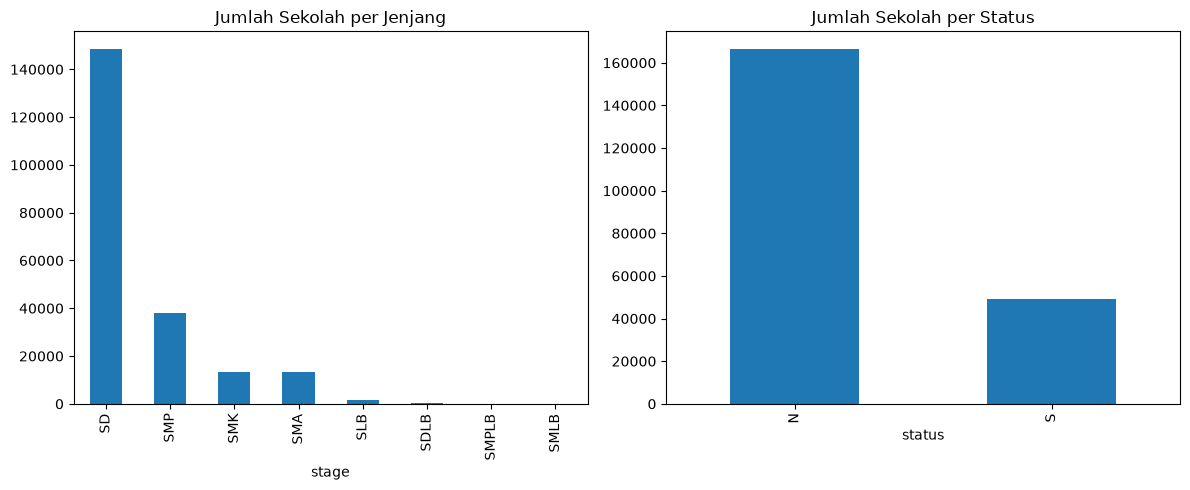

In [82]:
# Diagnostik: apakah nilai populasi konstan di level provinsi, atau bervariasi (misalnya per kota/kecamatan)?
variance_check = df4.groupby('province_name')['total_education_age_population'].nunique()
print(variance_check.sort_values(ascending=False).head(10))

# Visualisasi kategorikal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df4['stage'].value_counts().plot(kind='bar', ax=axes[0], title='Jumlah Sekolah per Jenjang')
df4['status'].value_counts().plot(kind='bar', ax=axes[1], title='Jumlah Sekolah per Status')
plt.tight_layout()
plt.show()

> nunique() == 1 untuk semua provinsi berarti nilai total_education_age_population (dan kemungkinan besar total_population juga) konstan di level provinsi. Jadi keunggulan data 4 dibanding data 3 sebenarnya hanya soal *recency* (BPS 2022 vs Sensus 2010), bukan granularitas, atau simpelnya: populasinya tetap di level provinsi, cuma tahun datanya lebih baru.

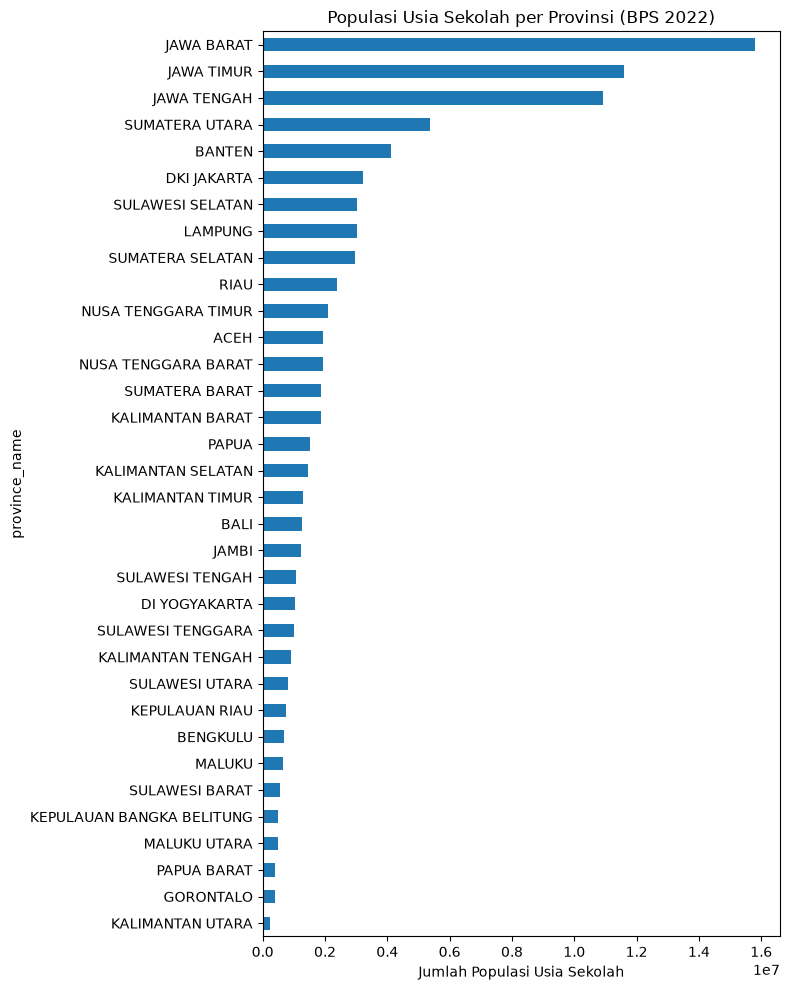

In [85]:
edu_pop_per_prov = df4.groupby('province_name')['total_education_age_population'].first().sort_values(ascending=False)

plt.figure(figsize=(8, 10))
edu_pop_per_prov.plot(kind='barh')
plt.title('Populasi Usia Sekolah per Provinsi (BPS 2022)')
plt.xlabel('Jumlah Populasi Usia Sekolah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [87]:
pop_variance_check = df4.groupby('province_name')['total_population'].nunique()
print(pop_variance_check.value_counts())

total_population
1    34
Name: count, dtype: int64


> total_population juga konstan per provinsi seperti total_education_age_population

> Karena *problem description* eksplisit menyebut FIRELINE fokus pada karhutla di Kalimantan, maka visualisasi selanjutnya akan berfokus pada 5 provinsi di Kalimantan untuk mengetahui kondisi spesifik di sana.

Jumlah sekolah di Kalimantan: 17549
province_name
KALIMANTAN BARAT      6247
KALIMANTAN SELATAN    3845
KALIMANTAN TENGAH     3810
KALIMANTAN TIMUR      2931
KALIMANTAN UTARA       716
Name: count, dtype: int64


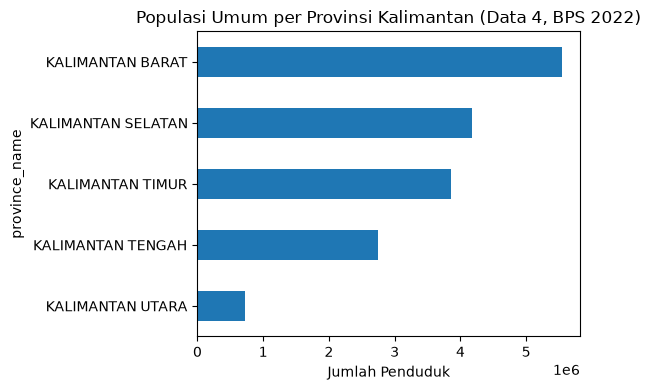

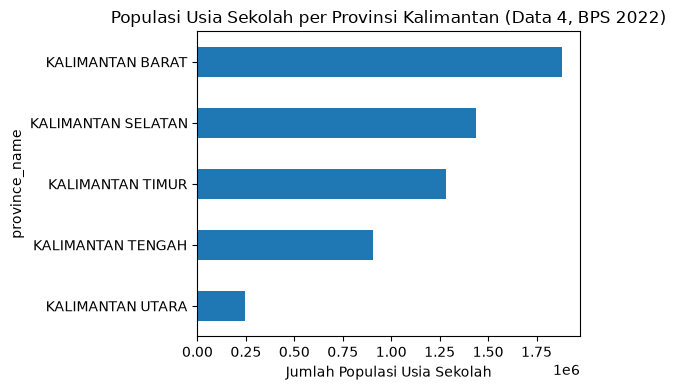

In [106]:
kalimantan_provinces = ['KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA']

df4_kalimantan = df4[df4['province_name'].isin(kalimantan_provinces)]
print("Jumlah sekolah di Kalimantan:", len(df4_kalimantan))
print(df4_kalimantan['province_name'].value_counts())

# Populasi umum per provinsi Kalimantan
pop_kalimantan = df4_kalimantan.groupby('province_name')['total_population'].first().sort_values()
plt.figure(figsize=(6,4))
pop_kalimantan.plot(kind='barh')
plt.title('Populasi Umum per Provinsi Kalimantan (Data 4, BPS 2022)')
plt.xlabel('Jumlah Penduduk')
plt.tight_layout()
plt.show()

# Populasi usia sekolah per provinsi Kalimantan
edu_pop_kalimantan = df4_kalimantan.groupby('province_name')['total_education_age_population'].first().sort_values()
plt.figure(figsize=(6,4))
edu_pop_kalimantan.plot(kind='barh')
plt.title('Populasi Usia Sekolah per Provinsi Kalimantan (Data 4, BPS 2022)')
plt.xlabel('Jumlah Populasi Usia Sekolah')
plt.tight_layout()
plt.show()

> Urutan provinsi konsisten antara populasi umum dan populasi usia sekolah (Kalbar > Kalsel > Kaltim > Kalteng > Kalut di keduanya). Artinya menunjukkan datanya koheren secara internal.

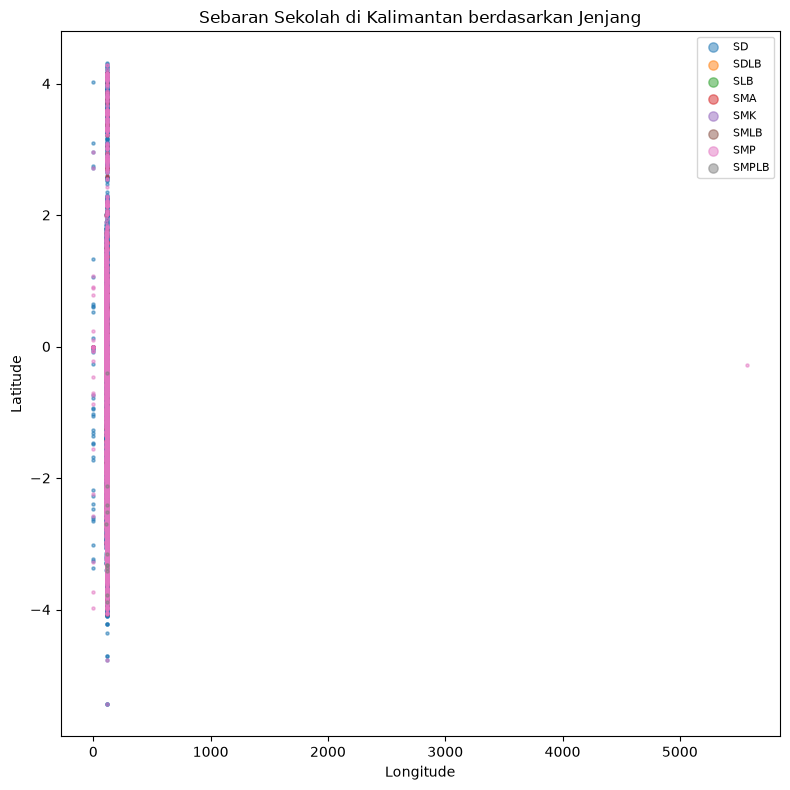

In [93]:
plt.figure(figsize=(8,8))
for stage_name, group in df4_kalimantan.dropna(subset=['lat','long']).groupby('stage'):
    plt.scatter(group['long'], group['lat'], s=5, alpha=0.5, label=stage_name)
plt.title('Sebaran Sekolah di Kalimantan berdasarkan Jenjang')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

**DOMAIN KNOWLEDGE**

> Ada noise visual tidak biasa, yaitu koordinat yang secara geografis tidak mungkin untuk Kalimantan. Longitude valid untuk Indonesia berkisar ~95–141; titik di longitude ~5.500 itu sudah keluar jauh dari rentang bumi yang masuk akal (longitude maksimum di bumi cuma ±180), jadi bisa dianggap kesalahan input data. Akan dilakukan *preprocessing*.

status      N    S
stage             
SD      11407  797
SDLB       13    3
SLB        46   34
SMA       729  370
SMK       348  346
SMLB        1    9
SMP      2711  723
SMPLB       2   10


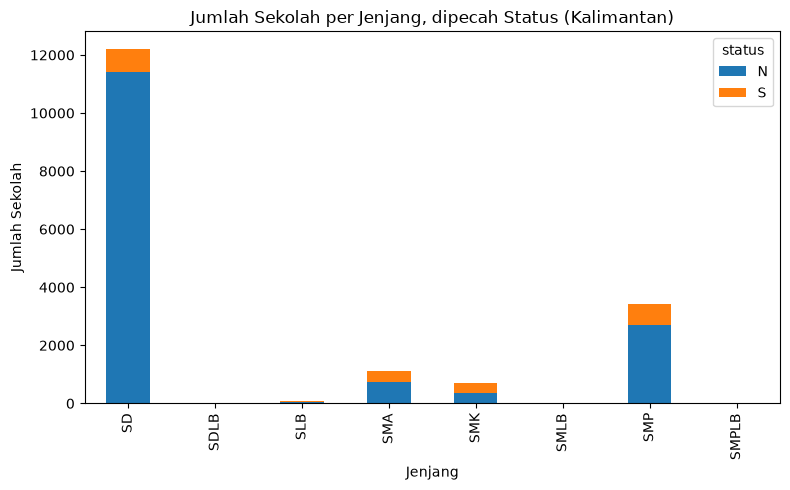

In [94]:
cross_tab = pd.crosstab(df4_kalimantan['stage'], df4_kalimantan['status'])
print(cross_tab)

cross_tab.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Jumlah Sekolah per Jenjang, dipecah Status (Kalimantan)')
plt.xlabel('Jenjang')
plt.ylabel('Jumlah Sekolah')
plt.tight_layout()
plt.show()

> Tidak ada isu, distribusi Negeri/Swasta per jenjang sudah jelas dan proporsional.

In [99]:
special_needs_stages = ['SLB', 'SDLB', 'SMPLB', 'SMLB']

df4_special_kalimantan = df4_kalimantan[df4_kalimantan['stage'].isin(special_needs_stages)]
print(df4_special_kalimantan.groupby('province_name')['stage'].value_counts())

province_name       stage
KALIMANTAN BARAT    SLB      16
                    SDLB      3
KALIMANTAN SELATAN  SLB      12
                    SDLB     10
                    SMPLB     9
                    SMLB      8
KALIMANTAN TENGAH   SLB      16
                    SDLB      3
                    SMPLB     2
                    SMLB      1
KALIMANTAN TIMUR    SLB      32
                    SMPLB     1
                    SMLB      1
KALIMANTAN UTARA    SLB       4
Name: count, dtype: int64


### PREPROCESSING

In [109]:
# Longitude valid untuk Indonesia kira-kira 95-141, latitude kira-kira -11 hingga 6
outlier_coord = df4_kalimantan[
    (df4_kalimantan['long'] > 141) | (df4_kalimantan['long'] < 95) |
    (df4_kalimantan['lat'] > 6) | (df4_kalimantan['lat'] < -11)
]
print(outlier_coord[['school_name', 'province_name', 'city_name', 'district_name', 'lat', 'long']])

# Tingkat nasional untuk tahu skala masalahnya
outlier_coord_all = df4[
    (df4['long'] > 141) | (df4['long'] < 95) |
    (df4['lat'] > 6) | (df4['lat'] < -11)
]
print("\nTotal baris dengan koordinat tidak valid (nasional):", len(outlier_coord_all))

                             school_name     province_name         city_name  \
83322                    SDN 26 SETAMBAH  KALIMANTAN BARAT       Kab. Sambas   
83422      SMP NEGERI 10 SATU ATAP TEBAS  KALIMANTAN BARAT       Kab. Sambas   
83665     SD NEGERI 26 TRANS NANGA SAHUI  KALIMANTAN BARAT  Kab. Kapuas Hulu   
83778   SD TUNAS SEJAHTERA SUNGAI TAWANG  KALIMANTAN BARAT  Kab. Kapuas Hulu   
83791        SD TUNAS PRIMA KHATULISTIWA  KALIMANTAN BARAT  Kab. Kapuas Hulu   
...                                  ...               ...               ...   
195743         SMP Muhammadiyah Longkali  KALIMANTAN TIMUR        Kab. Paser   
195819          SMP NEGERI 2 LONG HUBUNG  KALIMANTAN TIMUR  KAB. MAHAKAM ULU   
195842           SMP NEGERI 2 LONG BAGUN  KALIMANTAN TIMUR  KAB. MAHAKAM ULU   
195974       Sekolah Khusus Permata Hati  KALIMANTAN TIMUR    Kota Samarinda   
196310                    SD PELITA HATI  KALIMANTAN TIMUR   Kota Balikpapan   

                  district_name      la

In [116]:
# Pisahkan pola: sentinel (0,0) vs outlier ekstrem lain yang memang aneh
zero_coord_all = df4[(df4['lat'] == 0.0) & (df4['long'] == 0.0)]
print("Baris dengan lat=0 DAN long=0 (kemungkinan sentinel missing, nasional):", len(zero_coord_all))

nonzero_outlier = df4[
    ((df4['long'] > 141) | (df4['long'] < 95) | (df4['lat'] > 6) | (df4['lat'] < -11))
    & ~((df4['lat'] == 0.0) & (df4['long'] == 0.0))
]
print("Baris outlier lain (BUKAN sentinel 0,0), nasional:", len(nonzero_outlier))
print(nonzero_outlier[['school_name', 'province_name', 'city_name', 'district_name', 'lat', 'long']].to_string())

Baris dengan lat=0 DAN long=0 (kemungkinan sentinel missing, nasional): 184
Baris outlier lain (BUKAN sentinel 0,0), nasional: 532
                                            school_name              province_name                        city_name                  district_name         lat         long
221                                  SMP NEGERI ABENAHO                      PAPUA                      Kab. Yalimo                   Kec. Abenaho   -3.780600  6000.000000
681                       SD NEGERI 95 BENGKULU SELATAN                   BENGKULU            Kab. Bengkulu Selatan                  Kec. Pinoraya   -4.339800     0.000000
1085               SMP NEGERI 6 SATU ATAP TALIABU BARAT               MALUKU UTARA               KAB. PULAU TALIABU             Kec. Taliabu Barat   -1.887900     0.000000
1207                            SD NEGERI 1 TRANS WALEH               MALUKU UTARA            Kab. Halmahera Tengah                Kec. Weda Utara    0.465300     0.000000
1265     

> Beberapa baris yang ditemukan tidak wajar ternyata lat-nya sebenarnya masih masuk akal (misalnya -3,78 untuk Papua, -1,16 untuk Papua Barat), yang bermasalah cuma long-nya (6000 dan 300, jauh melebihi rentang wajar 95 - 141). Ini beda pola dari sentinel (0,0) tadi: bukan "kedua kolom kosong", tapi spesifik kolom long yang korup, sementara lat tetap valid.

In [114]:
# Cek pola: apakah cuma 'long' yang rusak, sementara 'lat' tetap valid?
print("Distribusi lat pada 532 baris outlier:")
print(nonzero_outlier['lat'].describe())

print("\nDistribusi long pada 532 baris outlier:")
print(nonzero_outlier['long'].describe())

lat_valid_long_invalid = nonzero_outlier[(nonzero_outlier['lat'] >= -11) & (nonzero_outlier['lat'] <= 6)]
print("\nJumlah baris dengan lat valid tapi long tidak valid:", len(lat_valid_long_invalid), "dari", len(nonzero_outlier))

Distribusi lat pada 532 baris outlier:
count    532.000000
mean      -1.629231
std        7.559296
min      -10.462300
25%       -4.633700
50%       -1.275000
75%        0.686170
max      108.210300
Name: lat, dtype: float64

Distribusi long pada 532 baris outlier:
count     532.000000
mean       59.402745
std       625.127806
min      -333.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      9720.000000
Name: long, dtype: float64

Jumlah baris dengan lat valid tapi long tidak valid: 526 dari 532


In [115]:
invalid_mask = (
    df4['lat'].isnull() | df4['long'].isnull() |
    ((df4['lat'] == 0.0) & (df4['long'] == 0.0)) |
    (df4['long'] > 141) | (df4['long'] < 95) |
    (df4['lat'] > 6) | (df4['lat'] < -11)
)
print("Total baris koordinat tidak valid (gabungan semua pola):", invalid_mask.sum())
print("Persentase dari total data:", round(invalid_mask.sum() / len(df4) * 100, 2), "%")

Total baris koordinat tidak valid (gabungan semua pola): 1866
Persentase dari total data: 0.87 %


Sekolah Kalimantan dgn koordinat valid: 17363 dari 17548


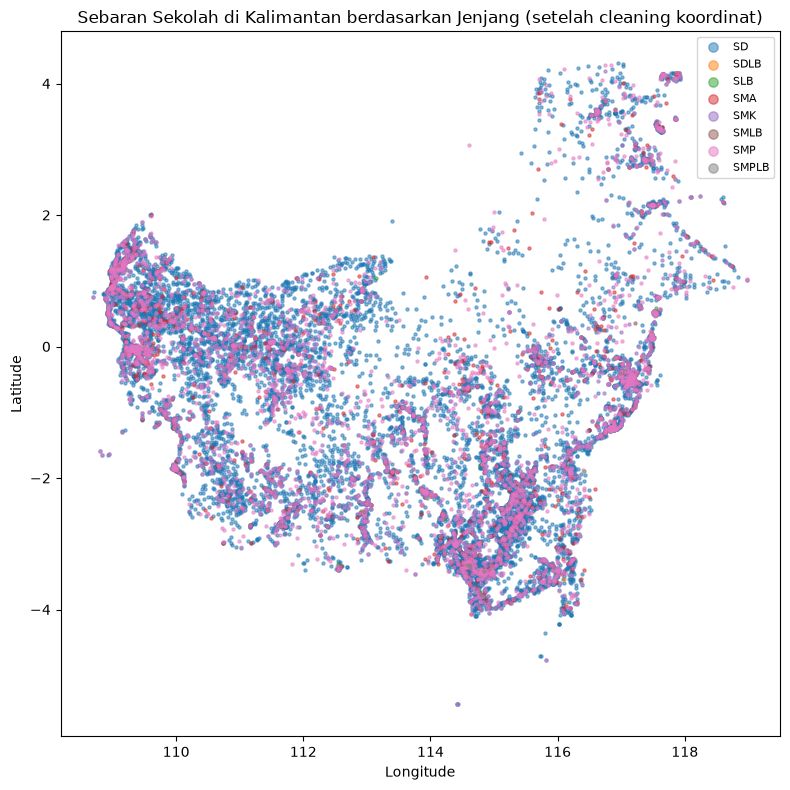

In [140]:
# Flag untuk baris dengan koordinat valid
invalid_mask = (
    df4['lat'].isnull() | df4['long'].isnull() |
    ((df4['lat'] == 0.0) & (df4['long'] == 0.0)) |
    (df4['long'] > 141) | (df4['long'] < 95) |
    (df4['lat'] > 6) | (df4['lat'] < -11)
)

df4['has_valid_coord'] = ~invalid_mask

# Ubah koordinat tidak valid jadi NaN
df4.loc[invalid_mask, ['lat', 'long']] = np.nan

# Re-filter Kalimantan dengan koordinat yang sudah bersih
df4_kalimantan = df4[df4['province_name'].isin(kalimantan_provinces)]
valid_kalimantan = df4_kalimantan.dropna(subset=['lat', 'long'])
print("Sekolah Kalimantan dgn koordinat valid:", len(valid_kalimantan), "dari", len(df4_kalimantan))

# Scatter plot ulang, tanpa outlier
plt.figure(figsize=(8,8))
for stage_name, group in valid_kalimantan.groupby('stage'):
    plt.scatter(group['long'], group['lat'], s=5, alpha=0.5, label=stage_name)
plt.title('Sebaran Sekolah di Kalimantan berdasarkan Jenjang (setelah cleaning koordinat)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

In [119]:
df4_original_pop = pd.read_csv('../datasets/complete_data.csv', usecols=['total_population'])
df4['total_population'] = df4_original_pop['total_population'].values

print("total_population dtype setelah dikoreksi:", df4['total_population'].dtype)
print(df4['total_population'].describe())

# Verifikasi 2 baris duplikat exact row
exact_dupes = df4[df4.duplicated(keep=False)]
print("\nBaris duplikat exact:")
print(exact_dupes[['school_name', 'province_name', 'city_name', 'lat', 'long']])

# Sampel duplikat nama+koordinat (86 baris terlibat)
valid_coord_df = df4.dropna(subset=['lat', 'long'])
name_coord_dupes = valid_coord_df[valid_coord_df.duplicated(subset=['school_name', 'lat', 'long'], keep=False)]
print(f"\n{len(name_coord_dupes)} baris terlibat duplikat nama+koordinat (10 contoh pertama):")
print(name_coord_dupes[['school_name', 'province_name', 'city_name', 'lat', 'long']].head(10))

total_population dtype setelah dikoreksi: float64
count    2.153710e+05
mean     2.057260e+07
std      1.811042e+07
min      7.277550e+05
25%      5.407855e+06
50%      1.067995e+07
75%      4.114997e+07
max      4.940581e+07
Name: total_population, dtype: float64

Baris duplikat exact:
           school_name province_name         city_name     lat      long
13809  SDN 3 MANONJAYA    JAWA BARAT  Kab. Tasikmalaya -7.3495  108.3093
14424  SDN 3 MANONJAYA    JAWA BARAT  Kab. Tasikmalaya -7.3495  108.3093
19140  SDN 4 CISEUREUH    JAWA BARAT   Kab. Purwakarta -6.5139  107.4652
19689  SDN 4 CISEUREUH    JAWA BARAT   Kab. Purwakarta -6.5139  107.4652

172 baris terlibat duplikat nama+koordinat (10 contoh pertama):
                  school_name province_name        city_name     lat      long
2672         SD N MEKARJAYA 1        BANTEN  Kab. Pandeglang -6.3817  105.8735
2893         SD N MEKARJAYA 1        BANTEN  Kab. Pandeglang -6.3817  105.8735
3426         SDN 2 BANJARSARI        BANTEN  

> Perlu dilihat apakah baris-baris yang sama nama dan koordinatnya ini juga sama di kolom *stage* (jenjang)? Karena kalau *stage*-nya beda (misal satu SD satu SMP di alamat yang sama, kasus umum sekolah satu atap/satu komplek), itu bukan duplikat *data quality*, tapi memang dua entitas sekolah berbeda yang lokasinya sama. Kalau *stage*-nya identik, baru itu baris duplikat.

In [120]:
dupe_check = df4[df4.duplicated(subset=['school_name','province_name','city_name','lat','long'], keep=False)]
print(dupe_check[['school_name','stage','status','lat','long']].sort_values(['school_name','lat','long']).head(20))

stage_variation = dupe_check.groupby(['school_name','province_name','city_name','lat','long'])['stage'].nunique()
print("\nDistribusi jumlah stage unik per grup duplikat:")
print(stage_variation.value_counts())

                     school_name stage status       lat        long
93093           SD GMIM SAWANGAN    SD      S  1.233800  125.008300
93222           SD GMIM SAWANGAN    SD      S  1.233800  125.008300
96921   SD INPRES KAMPUNG PARANG    SD      N -5.387563  119.404630
96979   SD INPRES KAMPUNG PARANG    SD      N -5.387563  119.404630
96583         SD INPRES MANDALLE    SD      N -5.261547  119.786015
96960         SD INPRES MANDALLE    SD      N -5.261547  119.786015
93108        SD INPRES TALIKURAN    SD      N  1.207600  124.784900
93119        SD INPRES TALIKURAN    SD      N  1.207600  124.784900
57907         SD ISLAM AL FURQON    SD      S -7.215100  112.759300
59043         SD ISLAM AL FURQON    SD      S -7.215100  112.759300
141871            SD ISLAM ANNUR    SD      S -6.310100  107.166300
142075            SD ISLAM ANNUR    SD      S -6.310100  107.166300
29711             SD N 2 SENDANG    SD      N -7.830400  111.210500
29933             SD N 2 SENDANG    SD      N -7

> Terkonfirmasi bahwa seluruh 172 baris punya stage identik di tiap grup duplikatnya, jadi ini baris duplikat (bukan sekolah beda jenjang yang kebetulan satu lokasi). Beda dengan kasus *missing* koordinat yang kita putuskan untuk di *flag* (karena baris itu masih membawa informasi baru meski koordinatnya kosong), duplikat murni seperti ini tidak membawa informasi tambahan apa pun, jadi aman dihapus.

In [121]:
before = len(df4)
df4 = df4.drop_duplicates(
    subset=['school_name', 'province_name', 'city_name', 'lat', 'long', 'stage'],
    keep='first'
).reset_index(drop=True)
after = len(df4)
print(f"Baris sebelum: {before}, sesudah: {after}, dihapus: {before - after}")

Baris sebelum: 215371, sesudah: 215285, dihapus: 86
